In [381]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [382]:
df = pd.read_csv("../data/raw/referee_appearances.csv")
df.head()

,key_id,tournament_id,tournament_name,match_id,match_name,match_date,stage_name,group_name,referee_id,family_name,given_name,country_name,confederation_id,confederation_name,confederation_code
0,1,WC-1930,1930 FIFA Men's World Cup,M-1930-01,France vs Mexico,1930-07-13,group stage,Group 1,R-251,Lombardi,Domingo,Uruguay,CF-4,South American Football Confederation,CONMEBOL
1,2,WC-1930,1930 FIFA Men's World Cup,M-1930-02,United States vs Belgium,1930-07-13,group stage,Group 4,R-260,Macías,José,Argentina,CF-4,South American Football Confederation,CONMEBOL
2,3,WC-1930,1930 FIFA Men's World Cup,M-1930-03,Yugoslavia vs Brazil,1930-07-14,group stage,Group 2,R-430,Tejada,Aníbal,Uruguay,CF-4,South American Football Confederation,CONMEBOL
3,4,WC-1930,1930 FIFA Men's World Cup,M-1930-04,Romania vs Peru,1930-07-14,group stage,Group 3,R-472,Warnken,Alberto,Chile,CF-4,South American Football Confederation,CONMEBOL
4,5,WC-1930,1930 FIFA Men's World Cup,M-1930-05,Argentina vs France,1930-07-15,group stage,Group 1,R-116,de Almeida Rêgo,Gilberto,Brazil,CF-4,South American Football Confederation,CONMEBOL


In [383]:
print(f"Raw data shape: {df.shape}")
print(f"Columns: {df.columns}")
print(f"Misisng values: \n{df.isnull().sum()}")

Raw data shape: (1248, 15)
Columns: Index(['key_id', 'tournament_id', 'tournament_name', 'match_id', 'match_name',
       'match_date', 'stage_name', 'group_name', 'referee_id', 'family_name',
       'given_name', 'country_name', 'confederation_id', 'confederation_name',
       'confederation_code'],
      dtype='object')
Misisng values: 
key_id                0
tournament_id         0
tournament_name       0
match_id              0
match_name            0
match_date            0
stage_name            0
group_name            0
referee_id            0
family_name           0
given_name            0
country_name          0
confederation_id      0
confederation_name    0
confederation_code    0
dtype: int64


In [384]:
# The card system was introduced in 1970; there was no such system prior to that, so we drop the previous tournaments

df["match_date"] = pd.to_datetime(df["match_date"])
df = df[df["match_date"].dt.year >= 1970]
df.head()

,key_id,tournament_id,tournament_name,match_id,match_name,match_date,stage_name,group_name,referee_id,family_name,given_name,country_name,confederation_id,confederation_name,confederation_code
200,201,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,Group 1,R-440,Tschenscher,Kurt,West Germany,CF-6,Union of European Football Associations,UEFA
201,202,WC-1970,1970 FIFA Men's World Cup,M-1970-02,Uruguay vs Israel,1970-06-02,group stage,Group 2,R-115,Davidson,Bobby,Scotland,CF-6,Union of European Football Associations,UEFA
202,203,WC-1970,1970 FIFA Men's World Cup,M-1970-03,England vs Romania,1970-06-02,group stage,Group 3,R-254,Loraux,Vital,Belgium,CF-6,Union of European Football Associations,UEFA
203,204,WC-1970,1970 FIFA Men's World Cup,M-1970-04,Peru vs Bulgaria,1970-06-02,group stage,Group 4,R-392,Sbardella,Antonio,Italy,CF-6,Union of European Football Associations,UEFA
204,205,WC-1970,1970 FIFA Men's World Cup,M-1970-05,Belgium vs El Salvador,1970-06-03,group stage,Group 1,R-358,Rădulescu,Andrei,Romania,CF-6,Union of European Football Associations,UEFA


In [385]:
# This work focuses on FIFA Men's World Cup only

df = df[df["tournament_name"].str.contains("Men's")]
print(f"Current data shape: {df.shape}")
df.head()

Current data shape: (764, 15)


,key_id,tournament_id,tournament_name,match_id,match_name,match_date,stage_name,group_name,referee_id,family_name,given_name,country_name,confederation_id,confederation_name,confederation_code
200,201,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,Group 1,R-440,Tschenscher,Kurt,West Germany,CF-6,Union of European Football Associations,UEFA
201,202,WC-1970,1970 FIFA Men's World Cup,M-1970-02,Uruguay vs Israel,1970-06-02,group stage,Group 2,R-115,Davidson,Bobby,Scotland,CF-6,Union of European Football Associations,UEFA
202,203,WC-1970,1970 FIFA Men's World Cup,M-1970-03,England vs Romania,1970-06-02,group stage,Group 3,R-254,Loraux,Vital,Belgium,CF-6,Union of European Football Associations,UEFA
203,204,WC-1970,1970 FIFA Men's World Cup,M-1970-04,Peru vs Bulgaria,1970-06-02,group stage,Group 4,R-392,Sbardella,Antonio,Italy,CF-6,Union of European Football Associations,UEFA
204,205,WC-1970,1970 FIFA Men's World Cup,M-1970-05,Belgium vs El Salvador,1970-06-03,group stage,Group 1,R-358,Rădulescu,Andrei,Romania,CF-6,Union of European Football Associations,UEFA


In [386]:
assert df["match_id"].nunique() == len(df)

The number of unique matches is the same as the length of `df`, meaning that there is one row for each map, so this dataset only includes the head official (referee) of the match (no assistant referees or VAR referees since 2018).

  confederation_code  count
0               UEFA    371
1           CONMEBOL    157
2                AFC     88
3           CONCACAF     87
4                CAF     57
5                OFC      4


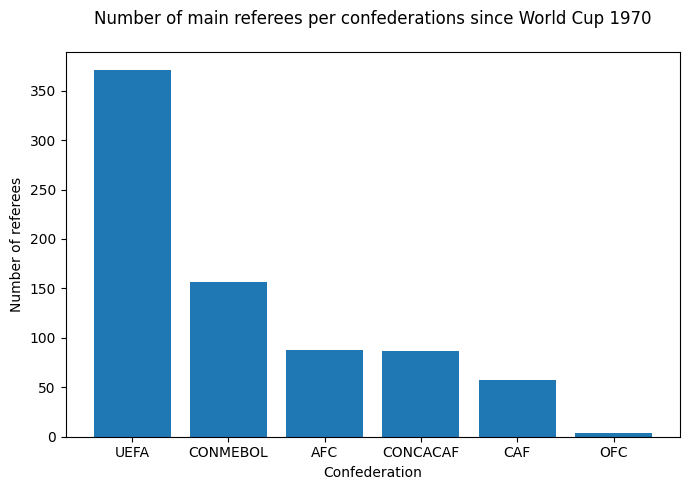

In [387]:
# visualization: bar chart of referees from each confederation

df_conf = pd.DataFrame(df["confederation_code"].value_counts()).reset_index()
print(df_conf)

plt.figure(figsize = (7, 5))
plt.bar(
    x = df_conf["confederation_code"],
    height = df_conf["count"]
)
plt.xlabel("Confederation")
plt.ylabel("Number of referees")
plt.title("Number of main referees per confederations since World Cup 1970", y = 1.05)
plt.tight_layout()
plt.savefig("../results/ref_count.png", bbox_inches = "tight")

In [388]:
df["stage_name"].unique()

array(['group stage', 'quarter-finals', 'semi-finals',
       'third-place match', 'final', 'second group stage', 'round of 16'],
      dtype=object)

In [389]:
# rename/fix duplicates in stage name

df["stage_name"] = df["stage_name"].str.replace("second group stage", "group stage")
df["stage_name"].unique()

array(['group stage', 'quarter-finals', 'semi-finals',
       'third-place match', 'final', 'round of 16'], dtype=object)

In [390]:
# pd.unstack => pivot the innermost index level into columns

stage = df["stage_name"].value_counts()
print(stage)
df_by_stage = df.groupby(['stage_name', 'confederation_code']).agg("size").unstack().reset_index()
df_by_stage = df_by_stage.fillna(0)
df_by_stage = pd.merge(df_by_stage, stage, on = "stage_name")
stage_order = ["group stage", "round of 16", "quarter-finals", "semi-finals", "final", "third-place match"]
df_by_stage = df_by_stage.set_index("stage_name").loc[stage_order].reset_index()
df_by_stage

stage_name
group stage          588
round of 16           80
quarter-finals        44
semi-finals           24
third-place match     14
final                 14
Name: count, dtype: int64


,stage_name,AFC,CAF,CONCACAF,CONMEBOL,OFC,UEFA,count
0,group stage,73.0,50.0,66.0,120.0,4.0,275.0,588
1,round of 16,5.0,2.0,10.0,16.0,0.0,47.0,80
2,quarter-finals,3.0,3.0,5.0,10.0,0.0,23.0,44
3,semi-finals,2.0,0.0,4.0,6.0,0.0,12.0,24
4,final,0.0,1.0,1.0,4.0,0.0,8.0,14
5,third-place match,5.0,1.0,1.0,1.0,0.0,6.0,14


In [391]:
# calculate the proportion of each stage's match officiated by refs from each confederation

conf_list = ["AFC", "CAF", "CONCACAF", "CONMEBOL", "OFC", "UEFA"]
for conf in conf_list:
    df_by_stage[conf] = df_by_stage[conf] / df_by_stage["count"]
df_by_stage = df_by_stage.drop(columns = "count")
df_by_stage

,stage_name,AFC,CAF,CONCACAF,CONMEBOL,OFC,UEFA
0,group stage,0.124150,0.085034,0.112245,0.204082,0.006803,0.467687
1,round of 16,0.062500,0.025000,0.125000,0.200000,0.000000,0.587500
2,quarter-finals,0.068182,0.068182,0.113636,0.227273,0.000000,0.522727
3,semi-finals,0.083333,0.000000,0.166667,0.250000,0.000000,0.500000
4,final,0.000000,0.071429,0.071429,0.285714,0.000000,0.571429
5,third-place match,0.357143,0.071429,0.071429,0.071429,0.000000,0.428571


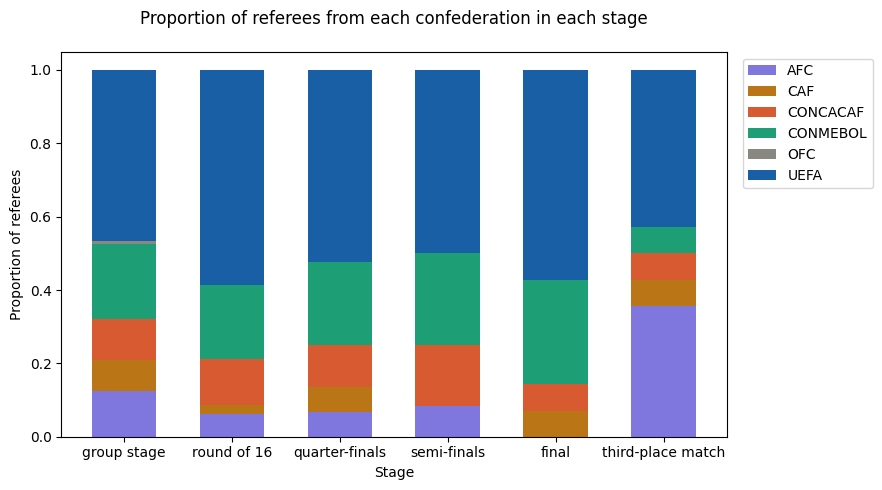

In [392]:
# visualization: stacked bar chart on the proportion of each confederation's refs in each stage

plt.figure(figsize = (9, 5))
plt.bar(
    x = df_by_stage["stage_name"],
    height = df_by_stage["AFC"],
    label = "AFC", 
    width = 0.6,
    color = "#7F77DD"
)
plt.bar(
    x = df_by_stage["stage_name"],
    height = df_by_stage["CAF"],
    bottom = df_by_stage["AFC"],
    label = "CAF", 
    width = 0.6,
    color = "#BA7517"
)
plt.bar(
    x = df_by_stage["stage_name"],
    height = df_by_stage["CONCACAF"],
    bottom = df_by_stage["AFC"] + df_by_stage["CAF"],
    label = "CONCACAF", 
    width = 0.6,
    color = "#D85A30"
)
plt.bar(
    x = df_by_stage["stage_name"],
    height = df_by_stage["CONMEBOL"],
    bottom = df_by_stage["AFC"] + df_by_stage["CAF"] + df_by_stage["CONCACAF"],
    label = "CONMEBOL", 
    width = 0.6,
    color = "#1D9E75"
)
plt.bar(
    x = df_by_stage["stage_name"],
    height = df_by_stage["OFC"],
    bottom = df_by_stage["AFC"] + df_by_stage["CAF"] + df_by_stage["CONCACAF"] + df_by_stage["CONMEBOL"],
    label = "OFC", 
    width = 0.6,
    color = "#888780"
)
plt.bar(
    x = df_by_stage["stage_name"],
    height = df_by_stage["UEFA"],
    bottom = df_by_stage["AFC"] + df_by_stage["CAF"] + df_by_stage["CONCACAF"] + df_by_stage["CONMEBOL"] + df_by_stage["OFC"],
    label = "UEFA", 
    width = 0.6,
    color = "#185FA5"
)
plt.legend(loc='upper right', bbox_to_anchor = (1.23, 1))
plt.xlabel("Stage")
plt.ylabel("Proportion of referees")
plt.title("Proportion of referees from each confederation in each stage", y = 1.05)
plt.tight_layout()
plt.savefig("../results/ref_stage.png", bbox_inches = "tight")

### Takeaways

- **UEFA referees** were consistenly dominant in all rounds at the World Cup, especially in high-stakes matches in the knock-out rounds. Critically, **57% of all World Cup finals** were officiated by refs from UEFA.
- **OFC referees** had really low appearances in all World Cup matches, as they disappear entirely from knock-out stages
- **CONMEBOL** and **CONCACAF referees** are respectively the second and third most present, as they appear in all stages. Nevertheless, their share didn't show a growth/dominance as that of UEFA does
- **CAF referees** officiated a small portion of matches from every stage, except that they never refereed one semi-final
- **AFC referees** disappear in final, but up to 38% of third-place matches were refereed by Asian refs. 

**Another story on the same data**: heatmap to detect some anomalous appearance of refs from certain confederations in certain stages

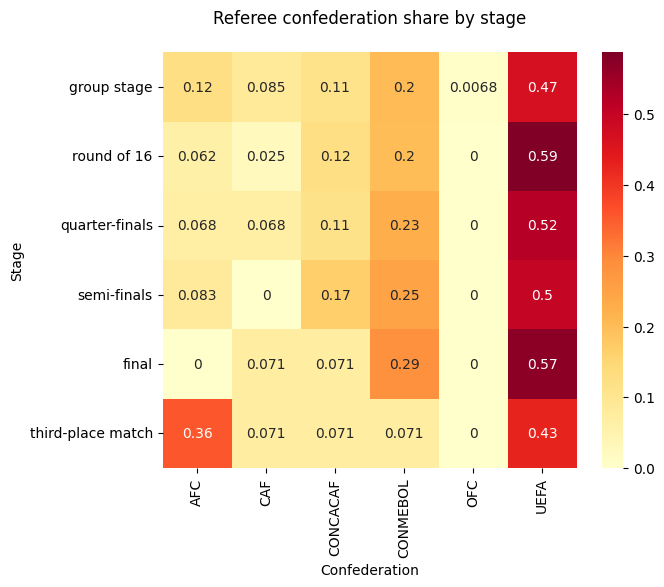

In [393]:
# visualization: heatmap of referee confederation share by stage

plt.figure(figsize = (7, 6))
ax = sns.heatmap(df_by_stage[["AFC", "CAF", "CONCACAF", "CONMEBOL", "OFC", "UEFA"]],
            annot = True, 
            cmap = 'YlOrRd', 
            vmin = None, 
            vmax = None)
ax.set_yticklabels(df_by_stage["stage_name"].values, rotation = 0)

plt.xlabel("Confederation")
plt.ylabel("Stage")
plt.title("Referee confederation share by stage", y = 1.05)
plt.tight_layout()
plt.savefig("../results/heatmap_ref_stage.png", bbox_inches = "tight")